# Compare ABL profiles

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D
import SANDwake3D_base as sdb

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# y-z mesh
dz   = 10
zmin = 5
zmax = zmin + 300
Nz   = int((zmax-zmin)/dz+1)
zvec = np.linspace(zmin,zmax,Nz)

dy   = 10
ymax = 100
Ny   = int((2*ymax)/dy+1)
yvec = np.linspace(-ymax,ymax,Ny)
#Ny=51
#ymax = 125
#yvec = np.linspace(-ymax,ymax,Ny)

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 10.0
dz = 10.0
(21, 31)


In [5]:
turbhh = 90.0
rotorD = 127
turbR  = rotorD*0.5

# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : 1.5E-5,
    'Cmu' : 5.48**(-2),
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':1,
    
    'ustar' : 0.289, #0.4, #0.575652,
    'qw': 0.0,
    'L' : float('inf'),
    'kappa' : 0.42,
    'z0' : 0.01,

    'zlo':zmin,
    'Tw':300,
    'beta':1.0/300.0,
    'Tref':300,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    
    'turbforcing':{'turbx':100.0,     # Turbine x location
                   'turby':0.0,     # Turbine y location
                   'zhh':turbhh,      # Turbine hub-height
                   'turbD':rotorD,   # Turbine diameter
                   'Ct':0.7,
                   'Rdelta':10,
                   'turbfunc':sdb.tanhADM,
                  }
}

# This parameter defines V(z) -- deg per meter
veerpermeter = 0.015 #0.02

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
veerProf = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerProf[i] = veerpermeter*(z-turbhh)

Uprof, Vprof = SANDwake3D.getUVfromUhVeer(UABL, veerProf)

# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, Uprof), np.interp(zbot, zvec, Uprof)
Vtop, Vbot = np.interp(ztop, zvec, Vprof), np.interp(zbot, zvec, Vprof)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  6.264029764642112
alpha =  0.11507912460260246
rotor veer =  1.9043151635232638


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*params['Tref']
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = Uprof[iz] #UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = Vprof[iz] #veerV[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*np.exp(-0.05*z) + 0.05 #0.025
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    
phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

(0.0, 305.0)

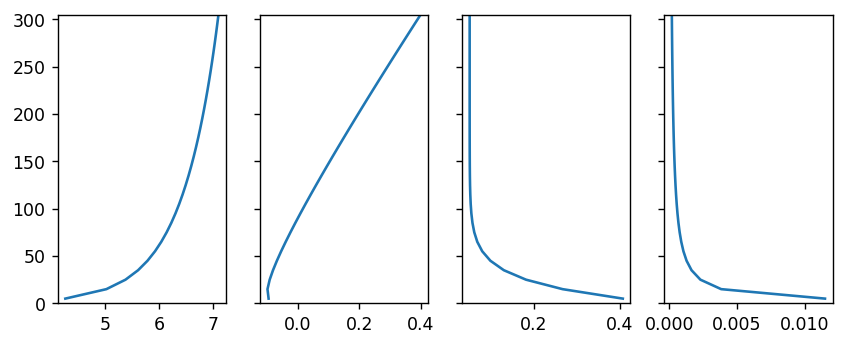

In [8]:
fig, axs = plt.subplots(1,4, sharey=True, dpi=125, figsize=(8,3))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Vinit[Ny//2,:], zvec)
axs[2].plot(Kinit[Ny//2,:], zvec)
axs[3].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [9]:
xvecplot=[0, 200, 400, 1000, 1200] #600, 1000]
dx  = 50 #150

xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec=[0, 200, 400, 600]

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, 
                             SANDwake3D.getTypicalWMBC(Uinit[0,-1], params['Tw'], veerBC=Vprof),
                             SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=2, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 50.0 dx = 50.0
[0] u: 6.5421e+00, w: 0.0000e+00, k: 9.4518e-01, eps: 3.6943e-02, T: 1.5936e-12, v: 1.4562e-01, p: 7.5551e-05
[1] u: 3.6132e+00, w: 2.6589e-06, k: 6.0414e-01, eps: 1.7085e-02, T: 2.1208e-12, v: 8.0414e-02, p: 5.2485e-05
[2] u: 1.1538e+00, w: 1.1840e-05, k: 2.2792e-01, eps: 6.7944e-03, T: 2.1548e-12, v: 2.5674e-02, p: 6.1959e-05
[3] u: 4.7171e-01, w: 1.3847e-05, k: 8.9386e-02, eps: 2.6451e-03, T: 2.0566e-12, v: 1.0497e-02, p: 1.7928e-05
[4] u: 1.7958e-01, w: 4.0067e-06, k: 3.4828e-02, eps: 1.0336e-03, T: 2.2844e-12, v: 3.9961e-03, p: 6.6932e-06
[5] u: 7.0786e-02, w: 1.4920e-06, k: 1.3611e-02, eps: 4.0370e-04, T: 2.4914e-12, v: 1.5752e-03, p: 2.6623e-06
[6] u: 2.7544e-02, w: 5.9304e-07, k: 5.3154e-03, eps: 1.5770e-04, T: 2.4862e-12, v: 6.1292e-04, p: 1.0263e-06
[7] u: 1.0775e-02, w: 2.2857e-07, k: 2.0765e-03, eps: 6.1600e-05, T: 2.2552e-12, v: 2.3977e-04, p: 4.0248e-07
[8] u: 4.2065e-03, w: 8.9627e-08, k: 8.1110e-04, eps: 2.4062e-05, T: 2.2169e-12, v: 9.3604e-05, p: 1.

(5.0, 305.0)

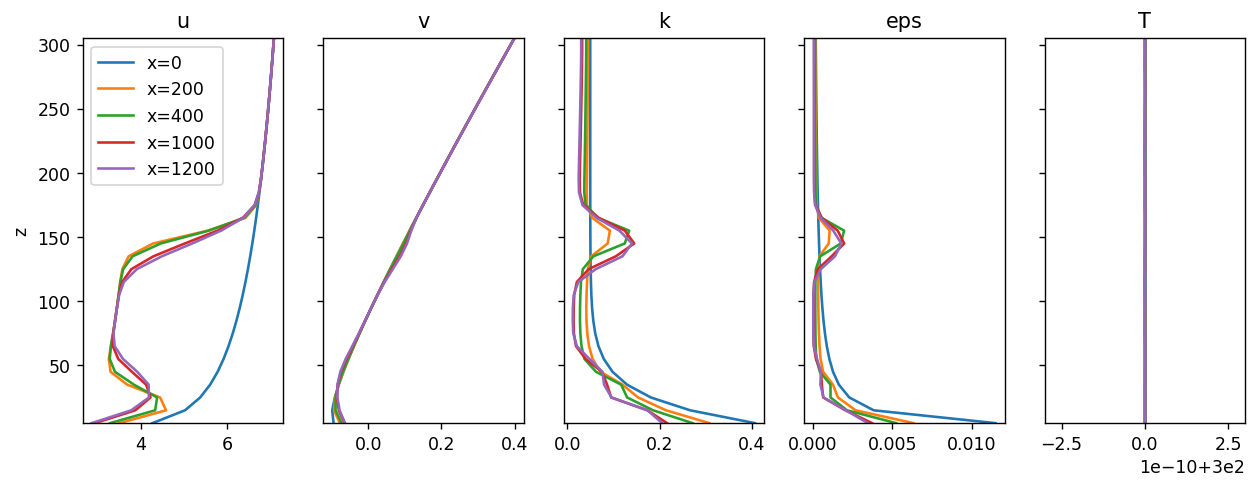

In [10]:
plotvars=['u', 'v', 'k', 'eps', 'T']
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()
islice = find_nearest(yvec, 0)# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,4), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

## Plot lidar data

In [11]:
def plotrotorlinesax(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line   

In [12]:
# Put the list of all cases in here
cases = [
    # AMR-Wind data defs
    {'label':'AMR-Wind',
     #'datadir':'../AMR.5kmX5km_noturbine1/post_processing/data_noturb',
     'datadir':'./',
     'prefix':'AMRWIND',
     'fname':'{prefix}_InflowProfiles_noturbine_x_-2.0D.dat',
     'linestyle':{'linestyle':'-', 'lw':2},
    },
        
]

Text(0.5, 0, 'TI [-]')

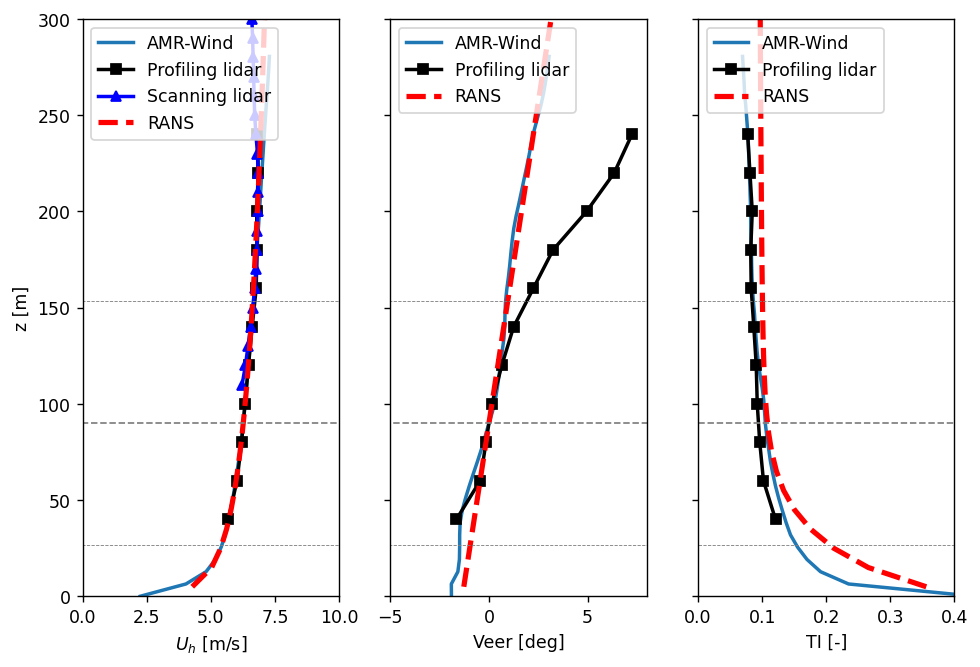

In [13]:
lidardir='./'

# Plot wind speed
WS_profiling = np.loadtxt(lidardir+'/Profiles_WindSpeed_a1_selectedcase_profiling.txt',delimiter=',')
WD_profiling = np.loadtxt(lidardir+'/Profiles_WindDirection_a1_selectedcase_profiling.txt',delimiter=',')
WS_scanning  = np.loadtxt(lidardir+'/Profiles_WindSpeed_a1_selectedcase_scanning.txt',delimiter=',') 
WD_zhh = np.interp(turbhh, WD_profiling[:,1], WD_profiling[:,0])

iRANS = 0
fig, axs = plt.subplots(1,3, figsize=(9,6), dpi=125, sharey=True)
for icase, case in enumerate(cases):
    label   = case['label']
    prefix  = case['prefix']
    datadir = case['datadir']
    fname   = case['fname'] 
    lstyle  = case['linestyle']
    dat=np.loadtxt(datadir+'/'+fname.format(prefix=prefix))
    z  = dat[:,0]
    uh = dat[:,1]
    
    # Plot Uh
    ax=axs[0]
    ax.plot(uh, z,  label=label, **lstyle)
    
    # Plot veer
    ax = axs[1]
    WD = dat[:,2]
    thetahh = np.interp(turbhh, z, WD)
    ax.plot(WD-thetahh, z, label=label, **lstyle)
    
    # Plot TI
    ax = axs[2]
    TI_horiz  = dat[:,5]
    ax.plot(TI_horiz, z,  label=label, **lstyle)
    #ax.plot(TI_profiling[:,0], TI_profiling[:,1], 'k-s',  lw=2)

# --- Plot lidar data ---
ax=axs[0]
ax.plot(WS_profiling[:,0], WS_profiling[:,1], 'k-', marker='s', label='Profiling lidar', lw=2)
ax.plot(WS_scanning[:,0],  WS_scanning[:,1],  'b-', marker='^', label='Scanning lidar', lw=2)
# Plot RANS data
Uh = np.sqrt(phi['u'][iRANS,islice,:]**2 + phi['v'][iRANS,islice,:]**2)
ax.plot(Uh, zvec, 'r--', lw=3, label='RANS')

# --- Plot veer ---
ax=axs[1]
ax.plot(WD_profiling[:,0]-WD_zhh, WD_profiling[:,1], 'k-s',  lw=2, label='Profiling lidar')
#plotrotorlinesax(ax, zhh, rotorD, -5,10, linestyles='dashed', color='gray',)
WD_RANS = np.arctan2(phi['v'][iRANS,islice,:], phi['u'][iRANS,islice,:])*180/np.pi
ax.plot(WD_RANS, zvec, 'r--', lw=3, label='RANS')
ax.set_xlim([-5, 8])
ax.set_xlabel('Veer [deg]')

# --- Plot TI ---
ax=axs[2]
TI_profiling = np.loadtxt(lidardir+'/Profiles_TurbInt_a1_selectedcase_profiling.txt',delimiter=',')
TI_scanning  = np.loadtxt(lidardir+'/Profiles_TurbInt_a1_selectedcase_scanning.txt',delimiter=',')
ax.plot(TI_profiling[:,0], TI_profiling[:,1], 'k-s',  lw=2, label='Profiling lidar')

# TKE = 0.5*(uu + vv + ww)  = 1.5*(uu)
# uu = 2/3*TKE
TI_RANS = np.sqrt((4.0/3.0)*phi['k'][iRANS,islice,:]/phi['u'][iRANS,islice,:])
ax.plot(TI_RANS, zvec, 'r--', lw=3, label='RANS')



for ax in axs:
    ax.set_ylim([0,300])
    ax.legend(loc='upper left')
    # Plot the turbine dimensions
    plotrotorlinesax(ax, turbhh, rotorD, -10, 20, linestyles='dashed', color='gray',)
    
ax=axs[0]
ax.set_xlim([0, 10])
ax.set_xlabel('$U_h$ [m/s]')
ax.set_ylabel('z [m]')

ax=axs[2]
ax.set_xlim([0, 0.4])
ax.set_xlabel('TI [-]')


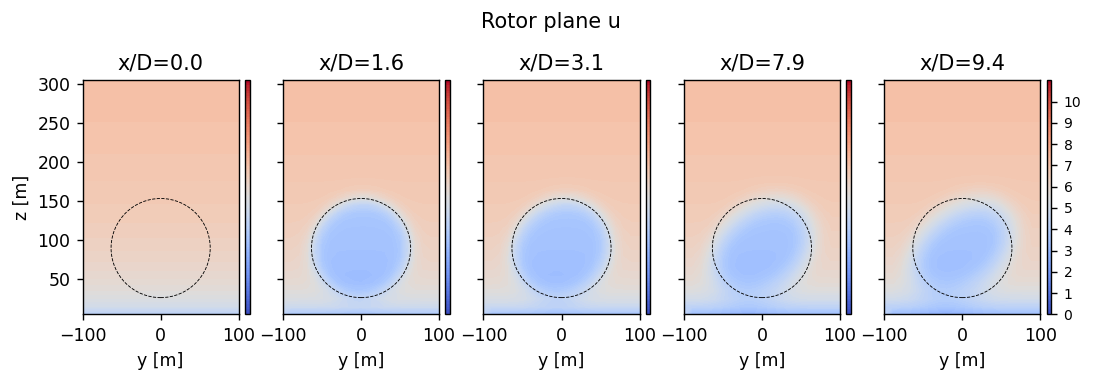

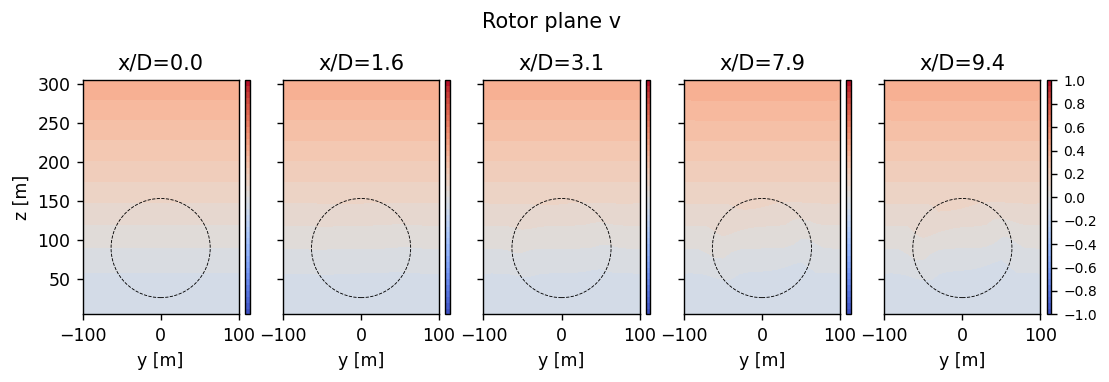

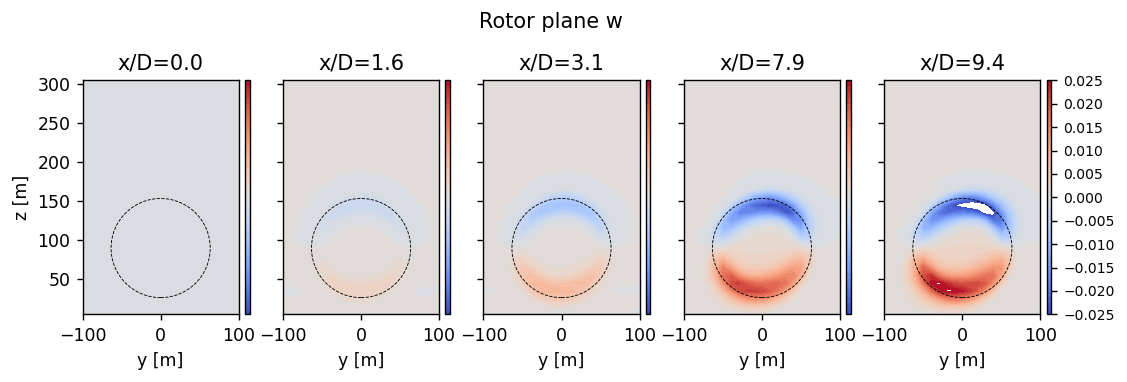

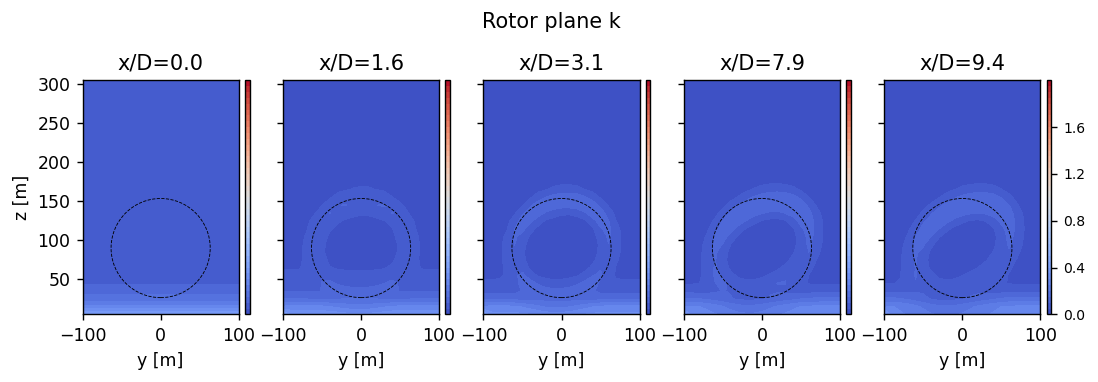

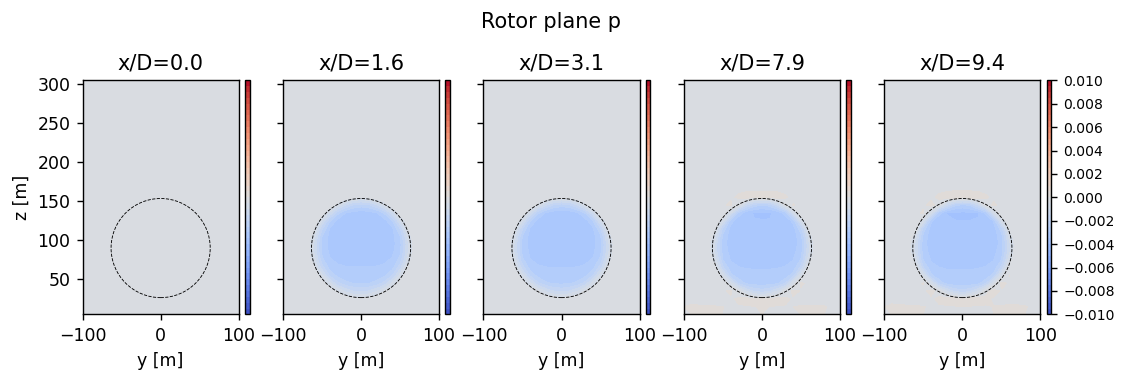

In [14]:
savefigs = False
cbarticks=np.arange(0,11,1)
plotvars=['u','v', 'w', 'k', 'p']
maxV=1
maxL=0.025
maxP=0.01
vlevels={'u':{'levels':np.linspace(0,11,91), 'cbarticks':np.arange(0,11,1)},
         'v':{'levels':np.linspace(-maxV,maxV,41), 'cbarticks':np.arange(-maxV, maxV+1E-5,maxV/5)},
         'w':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)}, 
         'k':{'levels':np.linspace(0,2,41), 'cbarticks':np.arange(0, 2,2.0/5)}, 
         'p':{'levels':np.linspace(-maxP,maxP,41), 'cbarticks':np.arange(-maxP, maxP+1E-5,maxP/5)}, 
        }

for plotv in plotvars:
    fig, axs = plt.subplots(1, len(xvecplot), figsize=(10,3.25), dpi=125, sharey=True)
    for ix, x in enumerate(xvecplot):
        ixRANS = find_nearest(xvec, x)
        c=axs[ix].contourf(ym, zm, phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
        axs[ix].set_aspect('equal')
        axs[ix].set_title('x/D=%.1f'%(0.5*x/turbR))
        axs[ix].set_xlabel('y [m]')
        rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', lw=0.5, fill=False)
        axs[ix].add_patch(rotorcirc)
    
        divider = make_axes_locatable(axs[ix])
        cax = divider.append_axes("right", size="3%", pad=0.05)
        if ix < len(xvecplot)-1:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
        else:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
            cbar.ax.tick_params(labelsize=8)
        
    axs[0].set_ylabel('z [m]')
    plt.suptitle('Rotor plane '+plotv,y=0.95)

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')